In [1]:
# Importer les packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import joblib as jb

In [2]:
# Supprimer les warning
import warnings
warnings.filterwarnings("ignore")

### <font color = 'bisque'>Importer et lire des données

In [3]:
# Import les données
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/apprentissage_supervisé_aihub/Regression/Doc 2/Car_data.csv")
df.head()

,Kms_Driven,Present_Price,Fuel_Type,Seller_Type,Transmission,Age,Selling_Price
0,27000,5.59,Petrol,Dealer,Manual,6,3.35
1,43000,9.54,Diesel,Dealer,Manual,7,4.75
2,6900,9.85,Petrol,Dealer,Manual,3,7.25
3,5200,4.15,Petrol,Dealer,Manual,9,2.85
4,42450,6.87,Diesel,Dealer,Manual,6,4.60


In [5]:
# Afficher les infos des données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5861 entries, 0 to 5860
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Kms_Driven     5861 non-null   int64  
 1   Present_Price  5861 non-null   float64
 2   Fuel_Type      5861 non-null   object 
 3   Seller_Type    5861 non-null   object 
 4   Transmission   5861 non-null   object 
 5   Age            5861 non-null   int64  
 6   Selling_Price  5861 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 320.7+ KB


### <font color = 'bisque'>Exploration et préparation des données

In [6]:
# sélection les variables quantitatives
quant_data = df.select_dtypes(include='number')
quant_data.head()

,Kms_Driven,Present_Price,Age,Selling_Price
0,27000,5.59,6,3.35
1,43000,9.54,7,4.75
2,6900,9.85,3,7.25
3,5200,4.15,9,2.85
4,42450,6.87,6,4.60


In [7]:
# décrire les variables quantitatives
quant_data.describe()

,Kms_Driven,Present_Price,Age,Selling_Price
count,5861.000000,5861.000000,5861.000000,5861.000000
mean,75209.206108,16.869948,8.562532,10.196217
std,39198.500980,9.659501,3.099993,5.874282
min,500.000000,0.320000,2.000000,0.100000
25%,53822.000000,10.552438,6.000000,6.401756
50%,71822.000000,15.375776,8.000000,9.049277
75%,87820.000000,19.229938,10.000000,11.873727
max,538824.000000,102.661886,22.000000,41.903189


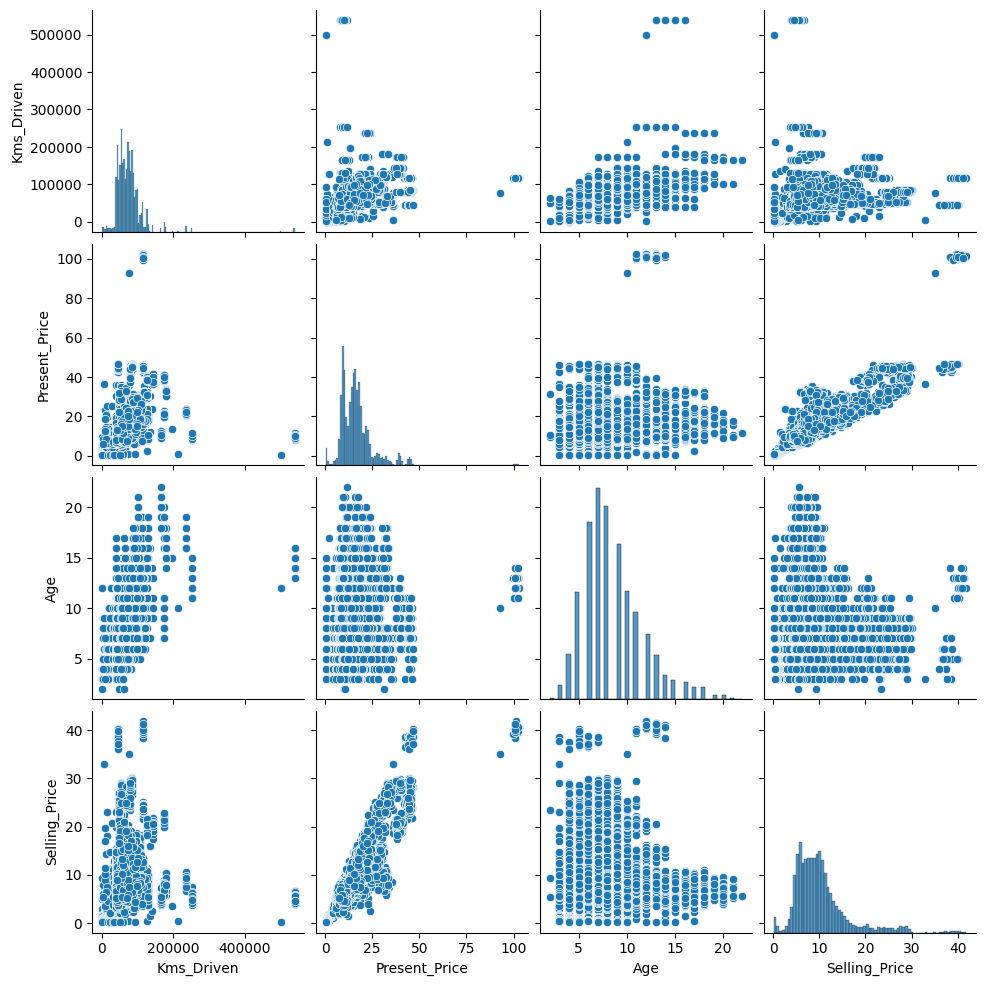

In [8]:
# pairplot des variables quantitatives
sns.pairplot(quant_data)
plt.show()

In [9]:
# Fonction permettant de visualiser les boxplots
def boxplot_func(col):
    fig = px.box(df, x=col)
    fig.show()

In [10]:
# Appliquer la fonctions boxplot_func
for col in quant_data.columns:
  boxplot_func(col)

In [11]:
# Afficher la matrice de corrélation
corr = quant_data.corr()
corr

,Kms_Driven,Present_Price,Age,Selling_Price
Kms_Driven,1.000000,0.249279,0.527629,0.065816
Present_Price,0.249279,1.000000,0.073940,0.870457
Age,0.527629,0.073940,1.000000,-0.188531
Selling_Price,0.065816,0.870457,-0.188531,1.000000


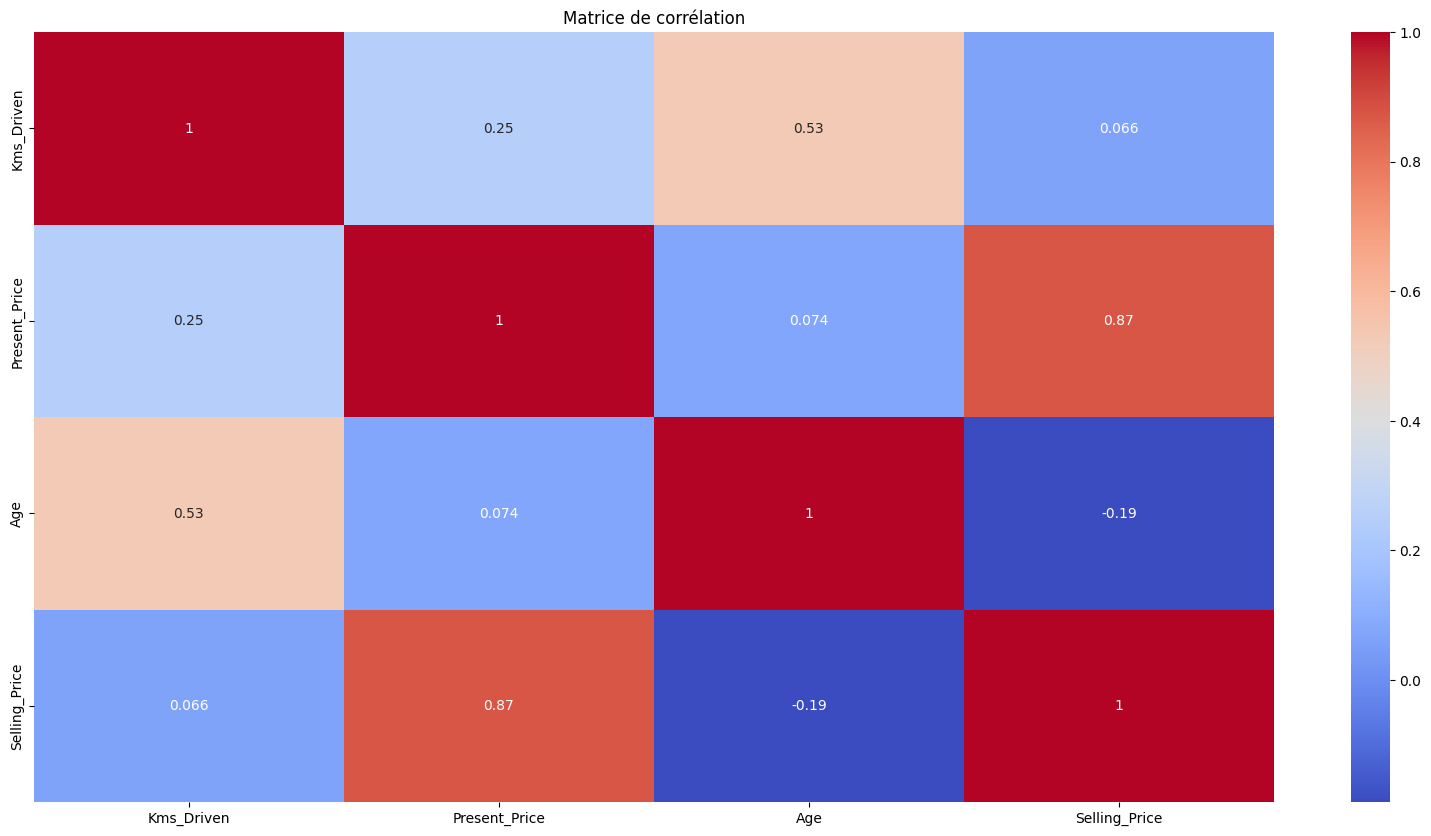

In [12]:
# Visualisaton le matrice de corrélation
plt.figure(figsize = (20, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()

In [13]:
# sélection les variables catégorielles
cat_data = df.select_dtypes(include='object')
cat_data.head()

,Fuel_Type,Seller_Type,Transmission
0,Petrol,Dealer,Manual
1,Diesel,Dealer,Manual
2,Petrol,Dealer,Manual
3,Petrol,Dealer,Manual
4,Diesel,Dealer,Manual


In [14]:
# décrire les variables catégorielles
cat_data.describe()

,Fuel_Type,Seller_Type,Transmission
count,5861,5861,5861
unique,3,2,2
top,Petrol,Dealer,Automatic
freq,2743,3765,3007


In [15]:
# Fonction de visualisaion du counplot
def countplot_func(col):
    val = cat_data[col].value_counts()
    fig = px.bar(x=val.index, y=val.values, color=val.index.astype(str), text_auto=True)
    fig.show()

In [16]:
# Appliquer la fonction countplot_func
for col in cat_data.columns:
  countplot_func(col)

### <font color = 'gold'>Preparation des données<font>

In [17]:
# Enregistrer les valeurs uniques des variables catégorielles (utile pour le déploiement)
uniques = []
for col in cat_data.columns:
  uniques.append(list(np.unique(df[col])))
jb.dump(uniques, 'uniques.joblib')

# Encoder les variables catégorielles en gardant un encodeur par colonne
from sklearn.preprocessing import LabelEncoder
encoders = [LabelEncoder() for _ in range(len(cat_data.columns))]
for i, col in enumerate(cat_data.columns):
  df[col] = encoders[i].fit_transform(df[col])
jb.dump(encoders, 'encoders.joblib')
df.head()

,Kms_Driven,Present_Price,Fuel_Type,Seller_Type,Transmission,Age,Selling_Price
0,27000,5.59,2,0,1,6,3.35
1,43000,9.54,1,0,1,7,4.75
2,6900,9.85,2,0,1,3,7.25
3,5200,4.15,2,0,1,9,2.85
4,42450,6.87,1,0,1,6,4.60


In [18]:
# Fonction d'imputation des valeurs aberrantes par la médiane
def imputation_func(df, col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  df[col] = np.where((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR)), df[col].mean(), df[col])

In [19]:
# imputer les valeurs aberrantes sur les variables prédictrices (Kms_Driven, Present_Price, Age)
for col in ['Kms_Driven', 'Present_Price', 'Age']:
  imputation_func(df, col)

# pour la cible Selling_Price : on retire les lignes trop extrêmes plutôt que de les imputer,
# pour ne pas fausser la distribution de la variable qu'on cherche à prédire
Q1 = df['Selling_Price'].quantile(0.25)
Q3 = df['Selling_Price'].quantile(0.75)
IQR = Q3 - Q1
indexes = list(df.loc[(df['Selling_Price'] < (Q1 - 1.5*IQR)) | (df['Selling_Price'] > (Q3 + 1.5*IQR))].index)
df.drop(indexes, axis=0, inplace=True)
df.shape

(5453, 7)

In [20]:
# réafficher les boxplots
for col in ['Kms_Driven', 'Present_Price', 'Age', 'Selling_Price']:
  boxplot_func(col)

##### <font color = 'bisque'> Fractionnement et normalisation

In [21]:
# Fractionner les données en variables prédicteurs (x) et variable cible (y)
# la variable cible est Selling_Price (dernière colonne)
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [22]:
# normaliser les données en utilisant StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)
jb.dump(scaler, 'scaler.joblib')
x[:5]

array([[-1.92279884, -1.69352922,  0.92158578, -0.75655536,  0.99688729,
        -0.89139815],
       [-1.22167692, -0.97283479, -0.44661658, -0.75655536,  0.99688729,
        -0.51800984],
       [-2.80358327, -0.91627396,  0.92158578, -0.75655536,  0.99688729,
        -2.01156305],
       [-2.87807747, -1.95626339,  0.92158578, -0.75655536,  0.99688729,
         0.22876676],
       [-1.24577798, -1.45998773, -0.44661658, -0.75655536,  0.99688729,
        -0.89139815]])

In [23]:
from sklearn.model_selection import train_test_split
# Splitter les données en train (80%), val (10%) et test (10%)
x_train, x_vt, y_train, y_vt = train_test_split(x, y, train_size=0.8, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_vt, y_vt, train_size=0.5, random_state=42)

### <font color = 'bisque'>Multiple Linear Regression<font>

In [24]:
# Rechercher les paramètres optimaux de l'algorithme
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
params = {'fit_intercept': [True, False], 'positive': [True, False]}
lr = LinearRegression()
grid_ = GridSearchCV(lr, params, cv=5)
grid_.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'fit_intercept': [True, False],
                         'positive': [True, False]})

In [25]:
# afficher les paramètres optimaux
print(grid_.best_params_)

# Entrainer la Linear Regression en utilisant les paramètres optimaux
lr_model = LinearRegression(**grid_.best_params_)
lr_model.fit(x_train, y_train)

{'fit_intercept': True, 'positive': False}


LinearRegression()

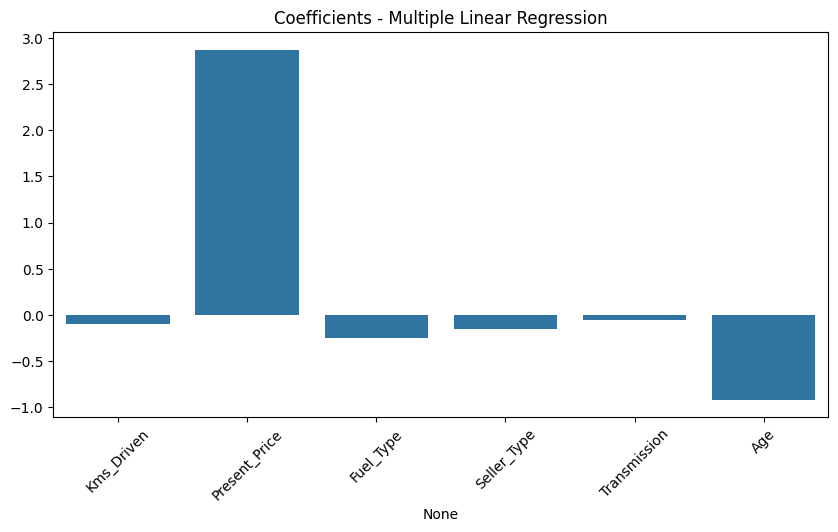

In [26]:
# Visualiser les coefs des variables à travers un barplot
plt.figure(figsize=(10,5))
sns.barplot(x=df.columns[:-1], y=lr_model.coef_)
plt.xticks(rotation=45)
plt.title("Coefficients - Multiple Linear Regression")
plt.show()

#### <font color = 'teal'> Evaluation du linear regression<font>

In [27]:
from sklearn.metrics import r2_score, mean_squared_error
# Calculer le R2 score et Mean Squarred Error sur les données de validation
y_pred = lr_model.predict(x_val)
r2_lr = r2_score(y_val, y_pred)
mse_lr = mean_squared_error(y_val, y_pred)
print(f"R2 : {r2_lr: .3f} --- MSE : {mse_lr: .3f}")

R2 :  0.668 --- MSE :  4.525


In [28]:
# Calculer le R2 score sur les données d'entrainement
y_pred_train = lr_model.predict(x_train)
print(f"R2 train : {r2_score(y_train, y_pred_train): .3f}")

R2 train :  0.681


### <font color = 'bisque'>Ridge Regression

In [29]:
# Rechercher les paramètres optimaux de l'algorithme
from sklearn.linear_model import Ridge
params = {'alpha': np.logspace(-8, 8, 100)}
rr = Ridge()
grid_ = GridSearchCV(rr, params, cv=5)
grid_.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': array([1.00000000e-08, 1.45082878e-08, 2.10490414e-08, 3.05385551e-08,
       4.43062146e-08, 6.42807312e-08, 9.32603347e-08, 1.35304777e-07,
       1.96304065e-07, 2.84803587e-07, 4.13201240e-07, 5.99484250e-07,
       8.69749003e-07, 1.26185688e-06, 1.83073828e-06, 2.65608778e-06,
       3.85352859e-06, 5.59081018e-06, 8.11130831e-06, 1....
       1.91791026e+04, 2.78255940e+04, 4.03701726e+04, 5.85702082e+04,
       8.49753436e+04, 1.23284674e+05, 1.78864953e+05, 2.59502421e+05,
       3.76493581e+05, 5.46227722e+05, 7.92482898e+05, 1.14975700e+06,
       1.66810054e+06, 2.42012826e+06, 3.51119173e+06, 5.09413801e+06,
       7.39072203e+06, 1.07226722e+07, 1.55567614e+07, 2.25701972e+07,
       3.27454916e+07, 4.75081016e+07, 6.89261210e+07, 1.00000000e+08])})

In [30]:
# Afficher le best paramètre
grid_.best_params_

{'alpha': np.float64(7.742636826811277)}

In [31]:
# Initialisation du modèle avec l'alpha optimal
ridge_model = Ridge(alpha=grid_.best_params_['alpha'])
ridge_model.fit(x_train, y_train)

Ridge(alpha=np.float64(7.742636826811277))

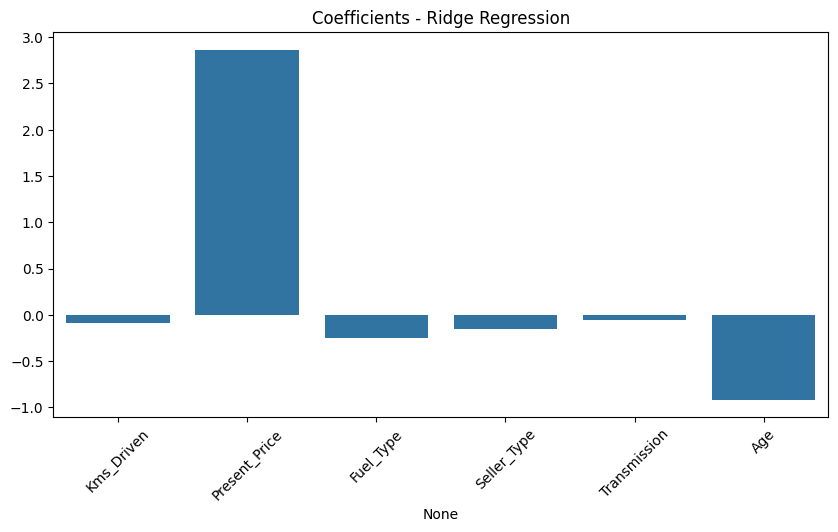

In [32]:
# Visualiser les coefs des variables à travers un barplot
plt.figure(figsize=(10,5))
sns.barplot(x=df.columns[:-1], y=ridge_model.coef_)
plt.xticks(rotation=45)
plt.title("Coefficients - Ridge Regression")
plt.show()

#### <font color = 'teal'> Evaluation du Ridge Regression<font>

In [33]:
# Calculer le R2 score et Mean Squarred Error
y_pred = ridge_model.predict(x_val)
r2_ridge = r2_score(y_val, y_pred)
mse_ridge = mean_squared_error(y_val, y_pred)
print(f"R2 : {r2_ridge: .3f} --- MSE : {mse_ridge: .3f}")

R2 :  0.668 --- MSE :  4.528


In [34]:
# Calculer le R2 score sur les données d'entrainement
y_pred_train = ridge_model.predict(x_train)
print(f"R2 train : {r2_score(y_train, y_pred_train): .3f}")

R2 train :  0.681


### <font color = 'bisque'>Lasso Regression<font>

In [35]:
# Rechercher les paramètres optimaux de l'algorithme
from sklearn.linear_model import Lasso
params = {'alpha': np.logspace(-8, 8, 100)}
lr2 = Lasso()
grid__ = GridSearchCV(lr2, params, cv=5)
grid__.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': array([1.00000000e-08, 1.45082878e-08, 2.10490414e-08, 3.05385551e-08,
       4.43062146e-08, 6.42807312e-08, 9.32603347e-08, 1.35304777e-07,
       1.96304065e-07, 2.84803587e-07, 4.13201240e-07, 5.99484250e-07,
       8.69749003e-07, 1.26185688e-06, 1.83073828e-06, 2.65608778e-06,
       3.85352859e-06, 5.59081018e-06, 8.11130831e-06, 1....
       1.91791026e+04, 2.78255940e+04, 4.03701726e+04, 5.85702082e+04,
       8.49753436e+04, 1.23284674e+05, 1.78864953e+05, 2.59502421e+05,
       3.76493581e+05, 5.46227722e+05, 7.92482898e+05, 1.14975700e+06,
       1.66810054e+06, 2.42012826e+06, 3.51119173e+06, 5.09413801e+06,
       7.39072203e+06, 1.07226722e+07, 1.55567614e+07, 2.25701972e+07,
       3.27454916e+07, 4.75081016e+07, 6.89261210e+07, 1.00000000e+08])})

In [36]:
# Afficher l'alpha optimal
grid__.best_params_

{'alpha': np.float64(0.00010974987654930568)}

In [37]:
# Initialiser le modèle
lasso_model = Lasso(alpha=grid__.best_params_['alpha'])
lasso_model.fit(x_train, y_train)

Lasso(alpha=np.float64(0.00010974987654930568))

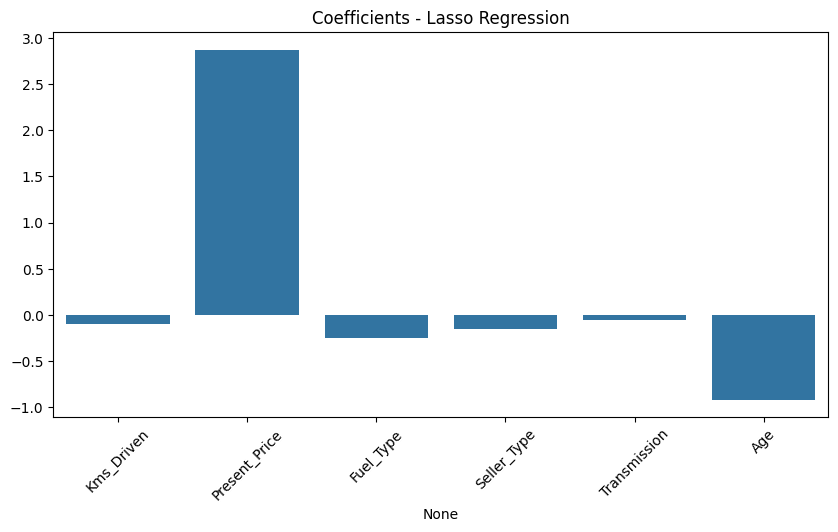

In [38]:
# Visualiser les coefs des variables à travers un barplot
plt.figure(figsize=(10,5))
sns.barplot(x=df.columns[:-1], y=lasso_model.coef_)
plt.xticks(rotation=45)
plt.title("Coefficients - Lasso Regression")
plt.show()

#### <font color = 'teal'> Evaluation du Lasso Regression<font>

In [39]:
# Calculer le R2 score et Mean Squarred Error
y_pred = lasso_model.predict(x_val)
r2_lasso = r2_score(y_val, y_pred)
mse_lasso = mean_squared_error(y_val, y_pred)
print(f"R2 : {r2_lasso: .3f} --- MSE : {mse_lasso: .3f}")

R2 :  0.668 --- MSE :  4.525


In [40]:
# Calculer le R2 score sur les données train
y_pred_train = lasso_model.predict(x_train)
print(f"R2 train : {r2_score(y_train, y_pred_train): .3f}")

R2 train :  0.681


### <font color = 'bisque'>Decision Tree Regressor<font>

In [41]:
# Recherche des paramètres optimaux du decision tree
from sklearn.tree import DecisionTreeRegressor
params = {'max_depth': np.arange(1, 15), 'criterion': ['squared_error', 'absolute_error']}
dt = DecisionTreeRegressor()
grid___ = GridSearchCV(dt, params, cv=5)
grid___.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])})

In [42]:
# Afficher les paramètres optimaux
grid___.best_params_

{'criterion': 'squared_error', 'max_depth': np.int64(8)}

In [43]:
# Entrainer le modèle decision tree sur les paramètres optimaux
dt_model = DecisionTreeRegressor(**grid___.best_params_)
dt_model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=np.int64(8))

#### <font color = 'teal'> Evaluation du Decision Tree<font>

In [44]:
# Calculer le R2 score et Mean Squarred Error
y_pred = dt_model.predict(x_val)
r2_dt = r2_score(y_val, y_pred)
mse_dt = mean_squared_error(y_val, y_pred)
print(f"R2 : {r2_dt: .3f} --- MSE : {mse_dt: .3f}")

R2 :  0.816 --- MSE :  2.509


In [45]:
# Calculer le R2 score sur les données train
y_pred_train = dt_model.predict(x_train)
print(f"R2 train : {r2_score(y_train, y_pred_train): .3f}")

R2 train :  0.882


### <font color = 'bisque'>Random Forest Regressor<font>

In [46]:
# Recherche des paramètres optimaux du Random Forest
from sklearn.ensemble import RandomForestRegressor
param_rf = {'n_estimators': list(np.arange(10, 100, 10)), 'max_depth': list(np.arange(3, 15))}
rf = RandomForestRegressor()
grid_rf = GridSearchCV(rf, param_rf, cv=5, n_jobs=-1)
grid_rf.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [np.int64(3), np.int64(4), np.int64(5),
                                       np.int64(6), np.int64(7), np.int64(8),
                                       np.int64(9), np.int64(10), np.int64(11),
                                       np.int64(12), np.int64(13),
                                       np.int64(14)],
                         'n_estimators': [np.int64(10), np.int64(20),
                                          np.int64(30), np.int64(40),
                                          np.int64(50), np.int64(60),
                                          np.int64(70), np.int64(80),
                                          np.int64(90)]})

In [47]:
# Afficher les paramètres optimaux
grid_rf.best_params_

{'max_depth': np.int64(12), 'n_estimators': np.int64(70)}

In [48]:
# Entrainer le Random Forest en utilisant les paramètres optimaux
rf_model = RandomForestRegressor(**grid_rf.best_params_)
rf_model.fit(x_train, y_train)

RandomForestRegressor(max_depth=np.int64(12), n_estimators=np.int64(70))

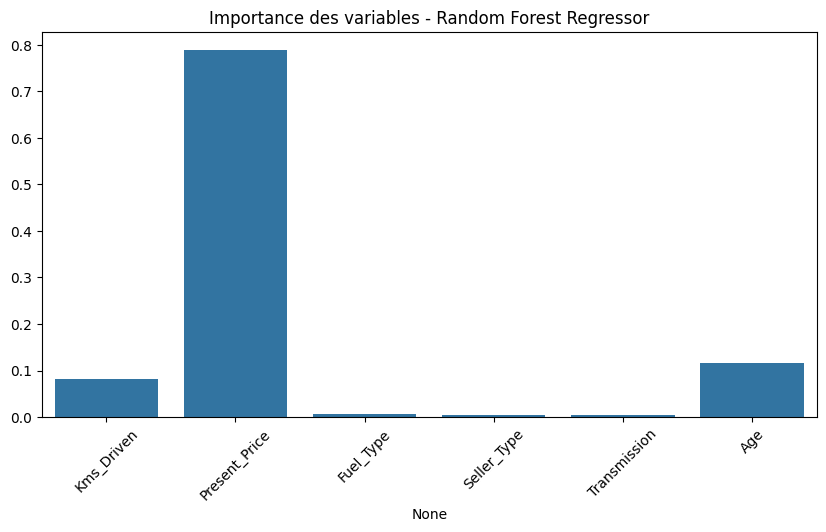

In [49]:
# Visualiser l'importance des variables à travers un barplot
plt.figure(figsize=(10,5))
sns.barplot(x=df.columns[:-1], y=rf_model.feature_importances_)
plt.xticks(rotation=45)
plt.title("Importance des variables - Random Forest Regressor")
plt.show()

#### <font color = 'teal'> Evaluation du Random Forest Regressor<font>

In [50]:
# Calculer le R2 score et Mean Squarred Error
y_pred = rf_model.predict(x_val)
r2_rf = r2_score(y_val, y_pred)
mse_rf = mean_squared_error(y_val, y_pred)
print(f"R2 : {r2_rf: .3f} --- MSE : {mse_rf: .3f}")

R2 :  0.853 --- MSE :  1.997


In [51]:
# Calculer le R2 score sur les données d'entrainement
y_pred_train = rf_model.predict(x_train)
print(f"R2 train : {r2_score(y_train, y_pred_train): .3f}")

R2 train :  0.951


### <font color = 'bisque'>XGBoost Regressor<font>

In [52]:
# Recherche des paramètres optimaux du XGBoost
from xgboost import XGBRegressor
param_xgb = {'n_estimators': list(np.arange(10, 100, 20)), 'max_depth': list(np.arange(3, 10))}
xgb = XGBRegressor()
grid_xgb = GridSearchCV(xgb, param_xgb, cv=5, n_jobs=-1)
grid_xgb.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'max_depth': [np.int64(3), np.int64(4), np.int64(5),
                                       np.int64(6), np.int64(7), np.int64(8),
                                       np.int64(9)],
                         'n_estimators': [np.int64(10), np.int64(30),
                                          np.int64(50), np.int64(70),
                                          np.int64(90)]})

In [53]:
# Afficher les paramètres optimaux
grid_xgb.best_params_

{'max_depth': np.int64(6), 'n_estimators': np.int64(30)}

In [54]:
# Entrainer XGBoost en utilisant les paramètres optimaux
xgb_model = XGBRegressor(**grid_xgb.best_params_)
xgb_model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=np.int64(6),
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None,
             n_estimators=np.int64(30), n_jobs=None, num_parallel_tree=None, ...)

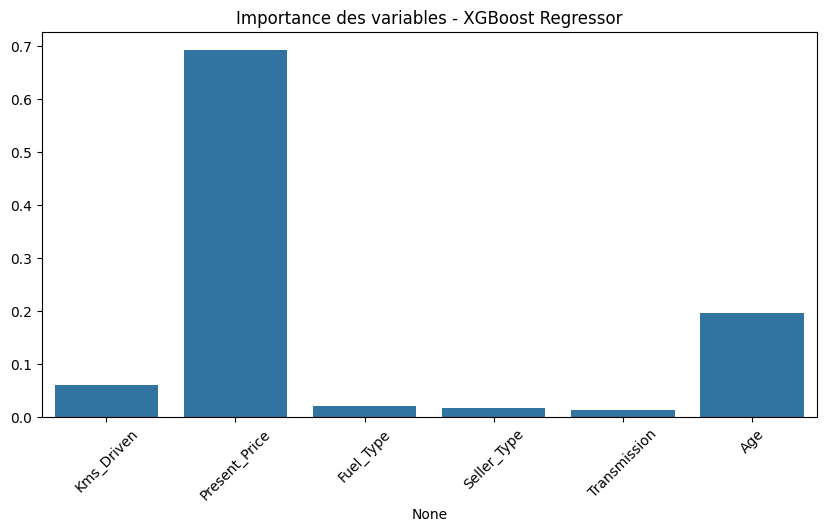

In [55]:
# Visualiser l'importance des variables à travers un barplot
plt.figure(figsize=(10,5))
sns.barplot(x=df.columns[:-1], y=xgb_model.feature_importances_)
plt.xticks(rotation=45)
plt.title("Importance des variables - XGBoost Regressor")
plt.show()

#### <font color = 'teal'> Evaluation du XGBoost Regressor<font>

In [56]:
# Calculer le R2 score et Mean Squarred Error
y_pred = xgb_model.predict(x_val)
r2_xgb = r2_score(y_val, y_pred)
mse_xgb = mean_squared_error(y_val, y_pred)
print(f"R2 : {r2_xgb: .3f} --- MSE : {mse_xgb: .3f}")

R2 :  0.848 --- MSE :  2.076


In [57]:
# Calculer le R2 score sur les données d'entrainement
y_pred_train = xgb_model.predict(x_train)
print(f"R2 train : {r2_score(y_train, y_pred_train): .3f}")

R2 train :  0.921


### <font color = 'bisque'>Tester le modèle le plus performant<font>

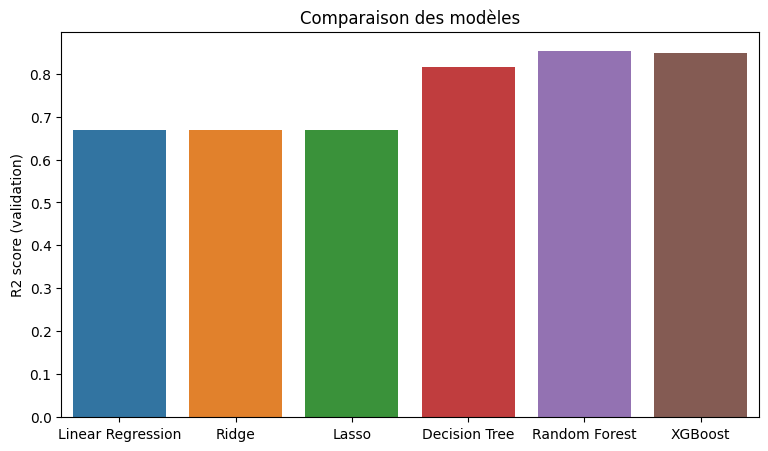

In [58]:
# Diagramme en barre de comparaison de tous les modèles (R2 sur validation)
list_r2 = [r2_lr, r2_ridge, r2_lasso, r2_dt, r2_rf, r2_xgb]
list_names = ['Linear Regression', 'Ridge', 'Lasso', 'Decision Tree', 'Random Forest', 'XGBoost']
plt.figure(figsize=(9,5))
sns.barplot(x=list_names, y=list_r2, hue=list_names)
plt.ylabel('R2 score (validation)')
plt.title('Comparaison des modèles')
plt.show()

In [59]:
# Sélection automatique du meilleur modèle (le plus grand R2 sur la validation)
models = {'Linear Regression': lr_model, 'Ridge': ridge_model, 'Lasso': lasso_model,
          'Decision Tree': dt_model, 'Random Forest': rf_model, 'XGBoost': xgb_model}
scores_r2 = dict(zip(list_names, list_r2))

best_name = max(scores_r2, key=scores_r2.get)
best_model = models[best_name]

print(f"Meilleur modèle (sur la validation, R2) : {best_name}  --  R2 = {scores_r2[best_name]: .3f}")

Meilleur modèle (sur la validation, R2) : Random Forest  --  R2 =  0.853


In [60]:
# Evaluation finale du meilleur modèle sur les données test
y_pred_test = best_model.predict(x_test)
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
print(f"[{best_name}] R2 test : {r2_test: .3f} --- MSE test : {mse_test: .3f}")

[Random Forest] R2 test :  0.873 --- MSE test :  1.698


In [61]:
# télécharger le meilleur modèle
jb.dump(best_model, 'best_model.joblib')
print(f"Modèle sauvegardé dans best_model.joblib : il s'agit du modèle {best_name}")

Modèle sauvegardé dans best_model.joblib : il s'agit du modèle Random Forest
